# Pipeline: `generate_sin_mts_smooth`

Visual decomposition of the smooth-sinusoidal generator into its stages:

1. AR(1) mother signal $m_t$ → min-max scaled to $\bar m_t \in [0,1]$.
2. Per-channel half-width $a_i$ defines a viewing window $[-a_i, +a_i]$ of the filter $g(y) = \tanh(k \sin y)/g_{\max}$.
3. Each channel: $X^{(i)}_t = g\!\left(2 a_i \bar m_t - a_i\right) + \varepsilon^{(i)}_t$.
4. Resulting MTS varies smoothly from linear-monotone to non-monotone across channels.

Parameters mirror `data/r_rho_mi/260323_g-tanhsin_k-2pi_noise_0.02_a-0.95_T2000`,
widest-$A$ variant `A-0.751pi_L-M-NM` (channels span all three regimes).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import pearsonr, spearmanr

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [3]:
# --- Parameters (from saved run meta.json) ---
M = 20
T = 2000
A = 0.751 * np.pi          # widest A-bin: spans L → M → NM
k = 2 * np.pi
ar1_a = 0.95
ar1_noise_std = 1.0
noise_std = 0.02           # fixed across channels for clarity
seed = 0                   # illustrative; not the saved-data seed

rng = np.random.default_rng(seed)
a_values = np.linspace(np.pi / 64, A, M)   # linspace=True
colors = cm.viridis(np.linspace(0, 1, M))

### 1. AR(1) mother signal $\to$ normalised $\bar m_t \in [0,1]$

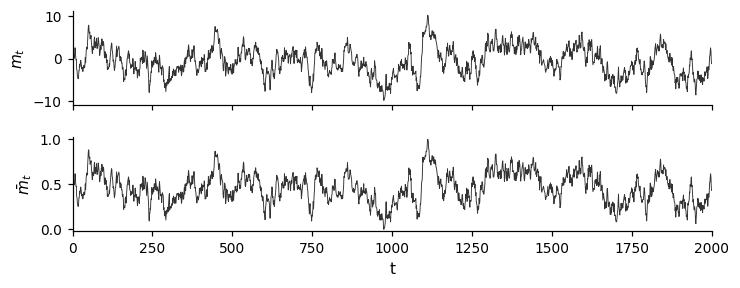

In [4]:
mother = np.zeros(T)
for t in range(1, T):
    mother[t] = ar1_a * mother[t - 1] + rng.normal(0, ar1_noise_std)
m_bar = (mother - mother.min()) / (mother.max() - mother.min())

fig, axes = plt.subplots(2, 1, figsize=(7.5, 2.6), sharex=True,
                         gridspec_kw={"hspace": 0.35})
axes[0].plot(mother, color="0.2", lw=0.6)
axes[0].set_ylabel(r"$m_t$")
axes[1].plot(m_bar, color="0.2", lw=0.6)
axes[1].set_ylabel(r"$\bar m_t$")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlabel("t")
for ax in axes:
    ax.set_xlim(0, T)
plt.show()

### 2. Filter $g(y) = \tanh(k \sin y)$ with per-channel viewing windows

Each channel only sees the arc of $g$ over $y \in [-a_i, +a_i]$. Small-$a_i$ channels traverse a near-linear segment near the origin; channels with $a_i > \pi/2$ extend past the extremum and become non-monotone in $\bar m_t$.

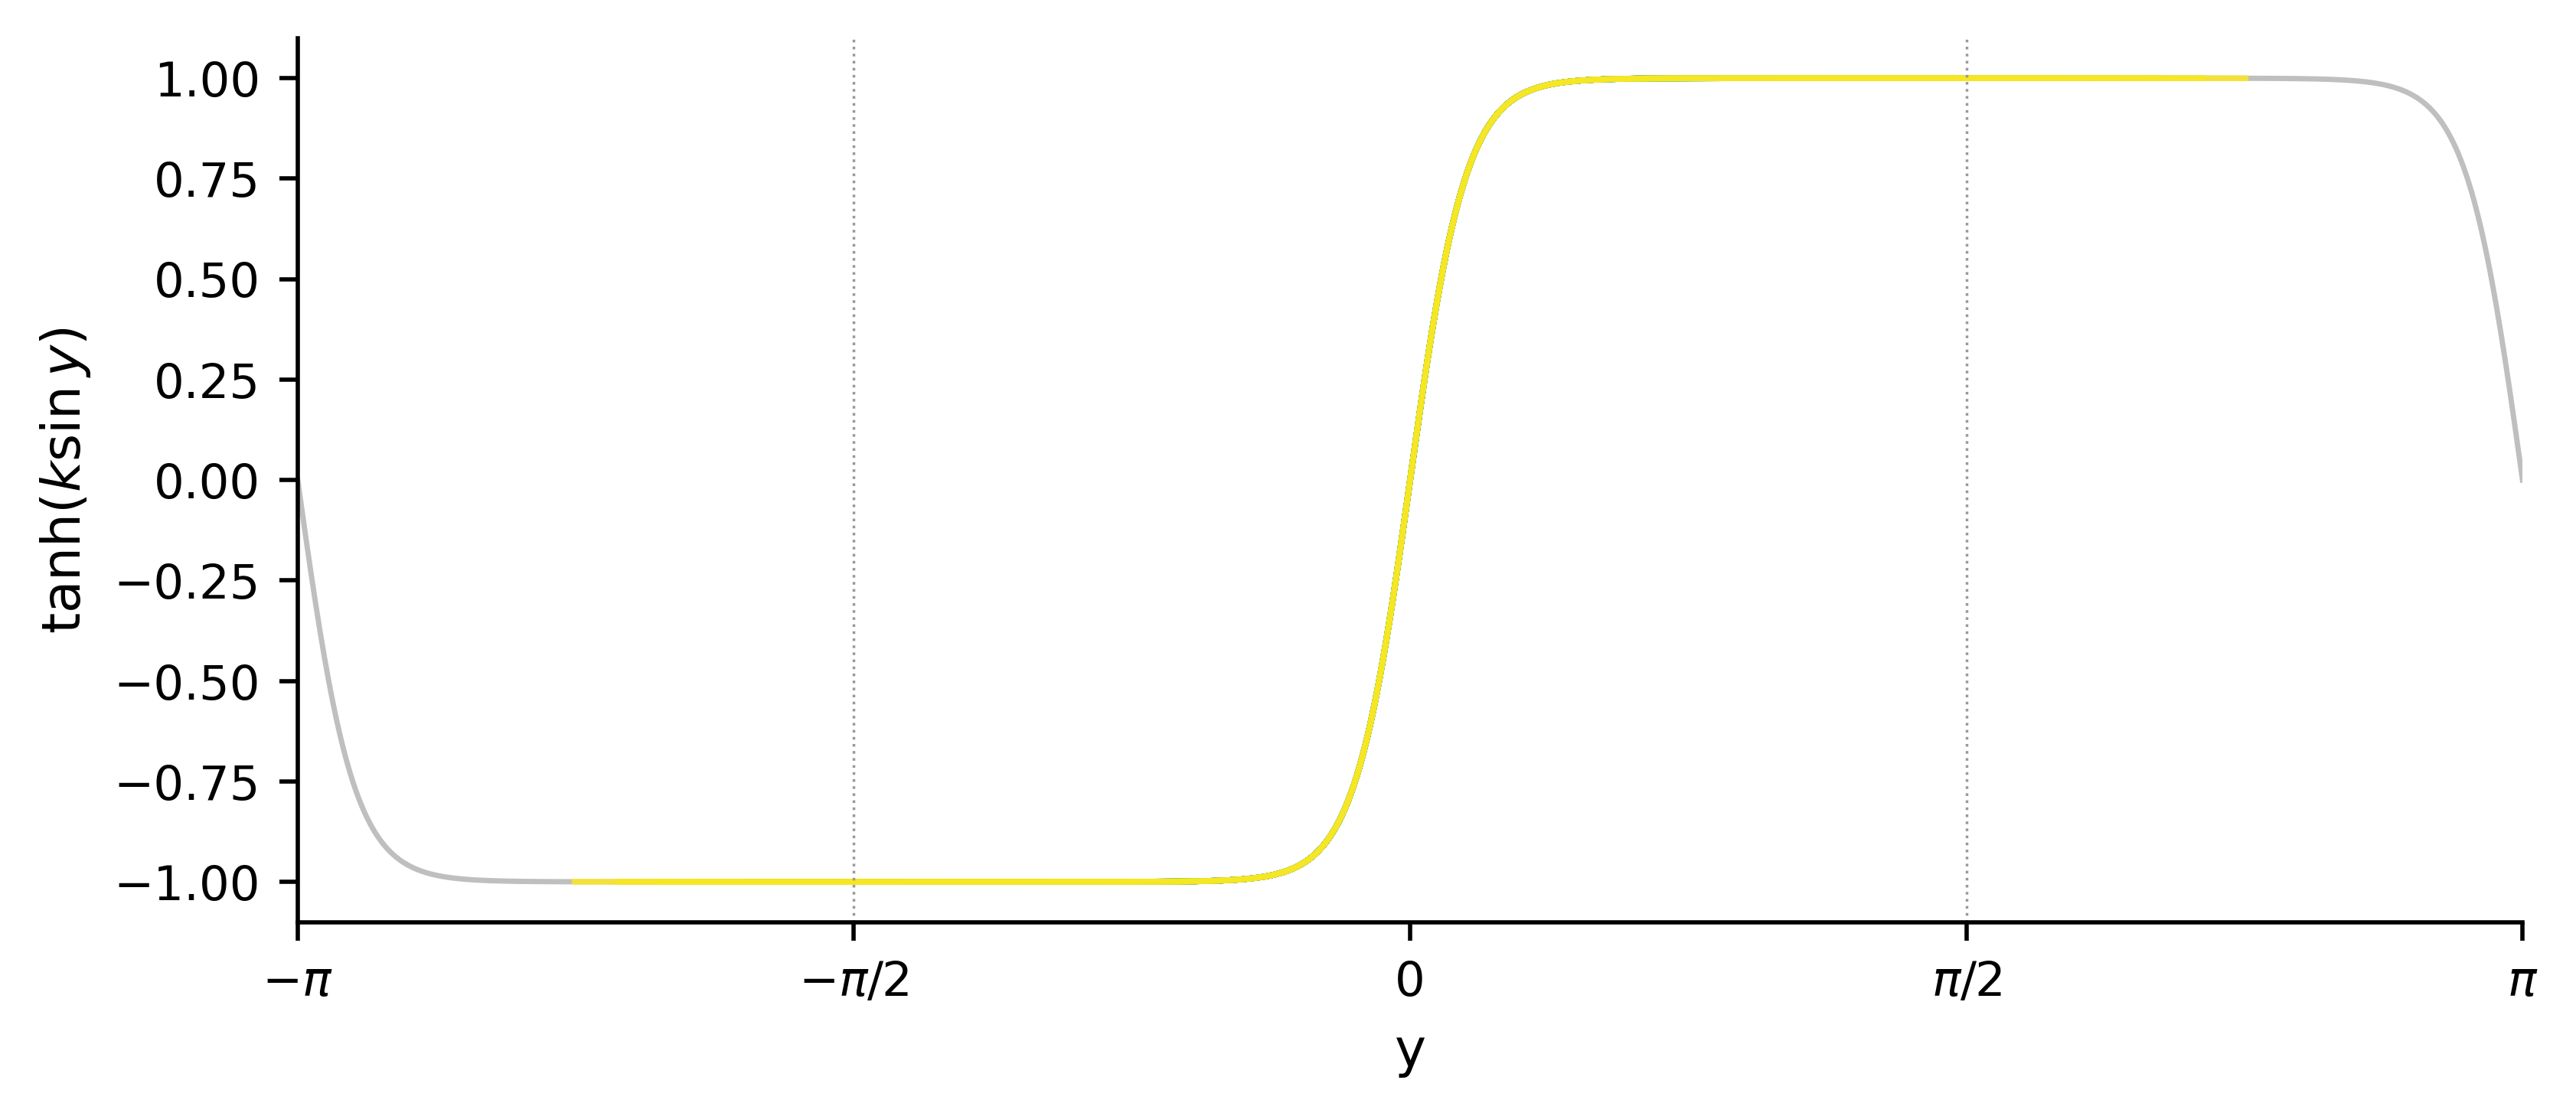

In [5]:
y_grid = np.linspace(-np.pi, np.pi, 1001)
g_grid = np.tanh(k * np.sin(y_grid))

fig, ax = plt.subplots(figsize=(7.5, 3.0),dpi=500)
ax.plot(y_grid, g_grid, color="0.75", lw=1.0, zorder=1)
for i, a_i in enumerate(a_values):
    yi = np.linspace(-a_i, a_i, 400)
    ax.plot(yi, np.tanh(k * np.sin(yi)), color=colors[i], lw=1.1, alpha=0.85)
for x in (-np.pi / 2, np.pi / 2):
    ax.axvline(x, color="0.6", lw=0.5, ls=":")
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
ax.set_xlabel("y"); ax.set_ylabel(r"$\tanh(k\sin y)$")
plt.show()

### 3. Per-channel half-widths $a_i$

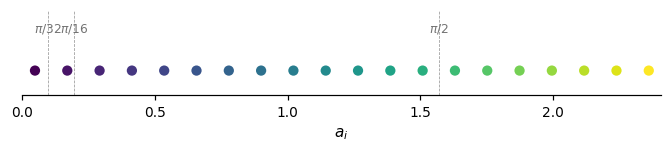

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 1.0))
ax.scatter(a_values, np.zeros(M), c=colors, s=45, zorder=3, edgecolor="none")
for x, lab in [(np.pi / 32, r"$\pi/32$"),
               (np.pi / 16, r"$\pi/16$"),
               (np.pi / 2,  r"$\pi/2$")]:
    if x <= A:
        ax.axvline(x, color="0.6", lw=0.5, ls="--")
        ax.text(x, 0.7, lab, ha="center", va="bottom", fontsize=8, color="0.45")
ax.set_xlim(0, A * 1.02)
ax.set_ylim(-0.5, 1.2)
ax.set_yticks([])
ax.set_xlabel(r"$a_i$")
ax.spines["left"].set_visible(False)
plt.show()

### 4. Channels $X^{(i)}_t = g(2 a_i \bar m_t - a_i)/g_{\max} + \varepsilon^{(i)}_t$

Stacked, colour-coded by $a_i$. Small-$a_i$ channels look like clean noisy copies of $\bar m$; large-$a_i$ channels show fold-overs each time $\bar m_t$ crosses a peak of $\sin$.

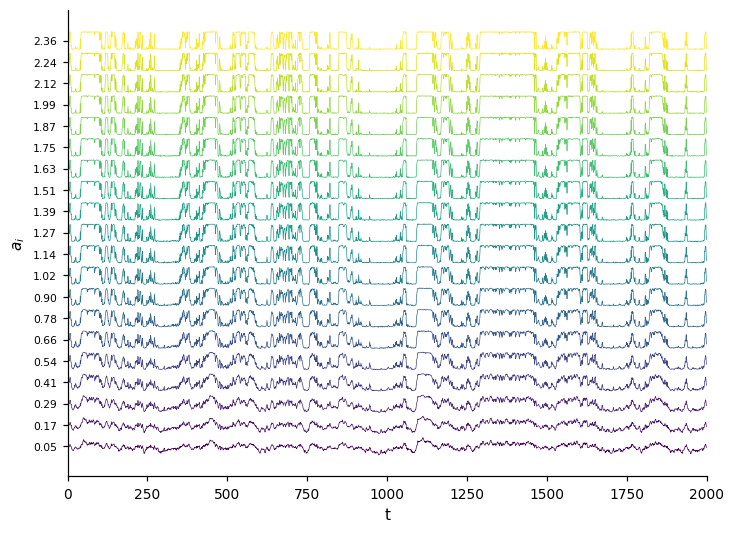

In [7]:
X = np.empty((T, M))
for i, a_i in enumerate(a_values):
    yi = 2 * a_i * m_bar - a_i
    g_max = np.tanh(k * np.sin(min(a_i, np.pi / 2)))
    X[:, i] = np.tanh(k * np.sin(yi)) / g_max + rng.normal(0, noise_std, T)

offset = 2.5
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i in range(M):
    ax.plot(X[:, i] + i * offset, color=colors[i], lw=0.45)
ax.set_xlim(0, T)
ax.set_xlabel("t")
ax.set_yticks([i * offset for i in range(M)])
ax.set_yticklabels([f"{a:.2f}" for a in a_values], fontsize=7)
ax.set_ylabel(r"$a_i$")
plt.show()

### 5. Exemplar pairwise scatters

$X^{(i)}_t$ vs $X^{(j)}_t$ for four representative pairs: small-small, small-mid, small-large, large-large.  The geometry maps directly onto where linear correlation departs from rank correlation.

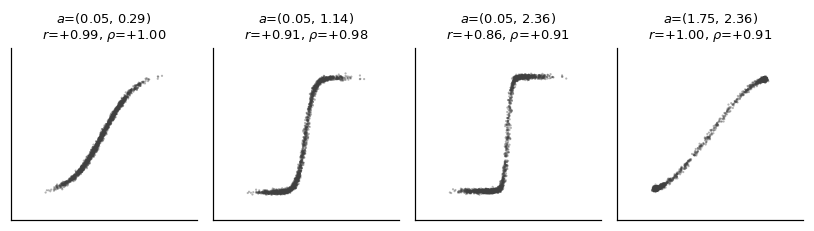

In [8]:
pairs = [(0, 2), (0, 9), (0, 19), (14, 19)]
fig, axes = plt.subplots(1, 4, figsize=(7.5, 2.2))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(X[:, i], X[:, j], s=2, alpha=0.4, color="0.25", edgecolor="none")
    r = pearsonr(X[:, i], X[:, j])[0]
    rs = spearmanr(X[:, i], X[:, j])[0]
    ax.set_title(f"$a$=({a_values[i]:.2f}, {a_values[j]:.2f})\n"
                 f"$r$={r:+.2f}, $\\rho$={rs:+.2f}", fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

### 6. Inter-channel dependency: $|r|$ and $|\rho|$ vs $\max(a_i, a_j)$

In this smooth-mother regime ($\phi_{AR}=0.95$, min-max normalised), $\bar m_t$ concentrates in the bulk and rarely visits the non-monotone arc, so absolute dependency stays high across all pairs.  The signal of interest is the **dissociation** between $|r|$ and $|\rho|$: small × large pairs typically show $|\rho| > |r|$ (Spearman tracks monotone distortion better), while saturated × saturated pairs can invert this through rank-ties induced by the steep filter.  Sweeping $A$ across runs — the `r_rho_mi` study — traces how this wedge widens with the regime mix.

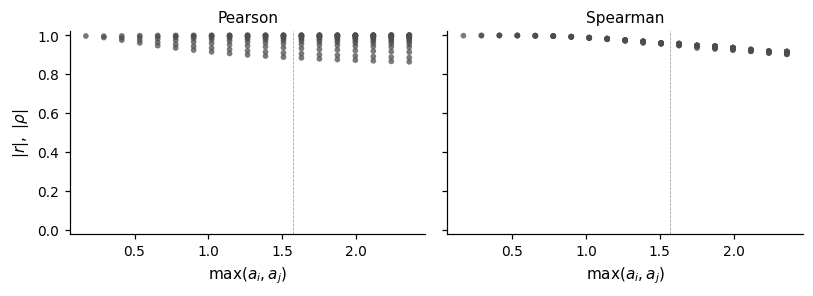

In [9]:
ii, jj = np.triu_indices(M, k=1)
r_p = np.array([pearsonr(X[:, i], X[:, j])[0] for i, j in zip(ii, jj)])
r_s = np.array([spearmanr(X[:, i], X[:, j])[0] for i, j in zip(ii, jj)])
max_a = np.maximum(a_values[ii], a_values[jj])

fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.8), sharey=True)
axes[0].scatter(max_a, np.abs(r_p), s=14, color="0.3", alpha=0.75, edgecolor="none")
axes[0].set_ylabel(r"$|r|,\ |\rho|$")
axes[0].set_title("Pearson", fontsize=10)
axes[1].scatter(max_a, np.abs(r_s), s=14, color="0.3", alpha=0.75, edgecolor="none")
axes[1].set_title("Spearman", fontsize=10)
for ax in axes:
    ax.axvline(np.pi / 2, color="0.6", lw=0.5, ls="--")
    ax.set_xlabel(r"$\max(a_i, a_j)$")
    ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()